In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(5)

# Варіант 5 — Дніпро
base_temp = 10.0
amplitude = 14
trend_per_year = 0.04
noise_scale = 1.0
city = "Дніпро"

n_years = 10

dates = pd.date_range(
    start="2015-01-01",
    periods=n_years * 12,
    freq="MS"
)

month = dates.month

years_elapsed = (
    (dates.year - dates.year[0])
    + (dates.month - 1) / 12
)

seasonal = (
    amplitude
    * np.cos(
        (month - 7) / 12 * 2 * np.pi
    )
)

trend = trend_per_year * years_elapsed

noise = np.random.normal(
    0,
    noise_scale,
    len(dates)
)

temp = np.round(
    base_temp + trend + seasonal + noise,
    1
)

climate_ts = pd.Series(
    temp,
    index=dates,
    name="температура"
)

print(climate_ts.head(12))
print("\nКількість місяців:", len(climate_ts))

2015-01-01    -3.6
2015-02-01    -2.5
2015-03-01     5.4
2015-04-01     9.8
2015-05-01    17.1
2015-06-01    23.7
2015-07-01    23.1
2015-08-01    21.6
2015-09-01    17.2
2015-10-01     9.7
2015-11-01     1.8
2015-12-01    -2.3
Freq: MS, Name: температура, dtype: float64

Кількість місяців: 120


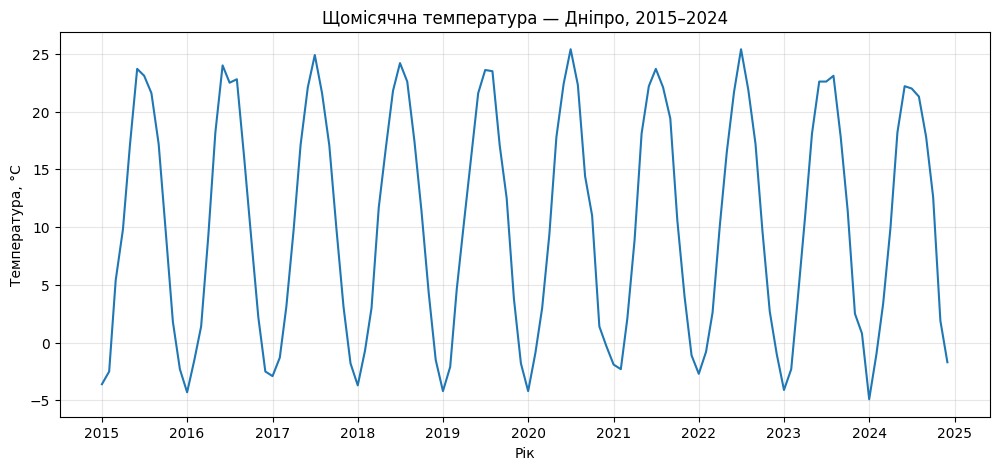

In [2]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    climate_ts.index,
    climate_ts.values
)

ax.set_xlabel("Рік")
ax.set_ylabel("Температура, °C")
ax.set_title(
    "Щомісячна температура — Дніпро, 2015–2024"
)

ax.grid(alpha=0.3)

plt.show()

На графіку чітко видно річну сезонність температури.

Щороку температура знижується взимку та досягає
максимальних значень у літні місяці, після чого
знову знижується.

Амплітуда сезонної складової становить близько
14 °C відносно середнього рівня.

Крім сезонних коливань, у дані закладено повільний
позитивний тренд:

0.04 °C на рік.

За 10 років це відповідає підвищенню приблизно
на 0.4 °C.

На сирому графіку цей тренд помітити значно важче,
ніж сезонність, оскільки сезонна амплітуда 14 °C
та випадковий шум близько 1 °C значно більші
за повільне щорічне підвищення температури.

Тому для кращого виділення тренду потрібно
згладити часовий ряд.

In [4]:
ma3 = climate_ts.rolling(
    window=3,
    center=True
).mean()

ma12_center = climate_ts.rolling(
    window=12,
    center=True
).mean()

ma12_trailing = climate_ts.rolling(
    window=12
).mean()

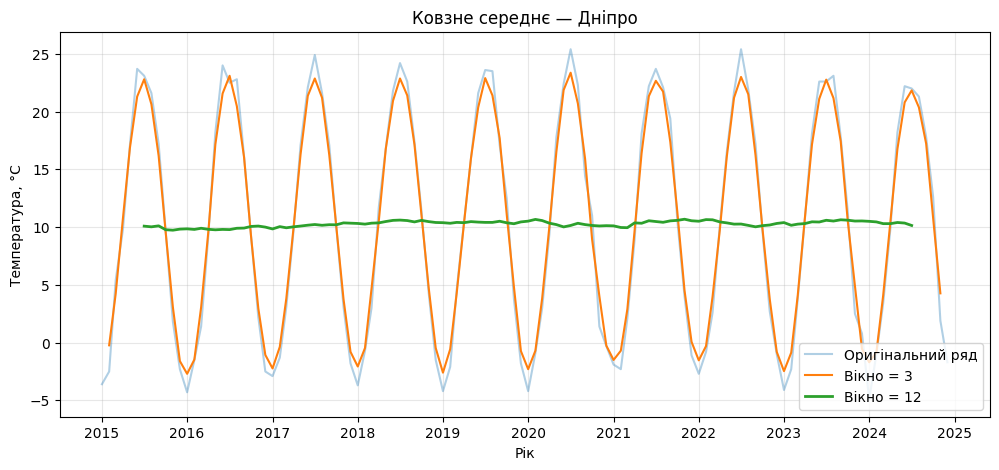

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    climate_ts.index,
    climate_ts.values,
    alpha=0.35,
    label="Оригінальний ряд"
)

ax.plot(
    ma3.index,
    ma3.values,
    label="Вікно = 3"
)

ax.plot(
    ma12_center.index,
    ma12_center.values,
    linewidth=2,
    label="Вікно = 12"
)

ax.set_xlabel("Рік")
ax.set_ylabel("Температура, °C")
ax.set_title("Ковзне середнє — Дніпро")

ax.legend()
ax.grid(alpha=0.3)

plt.show()

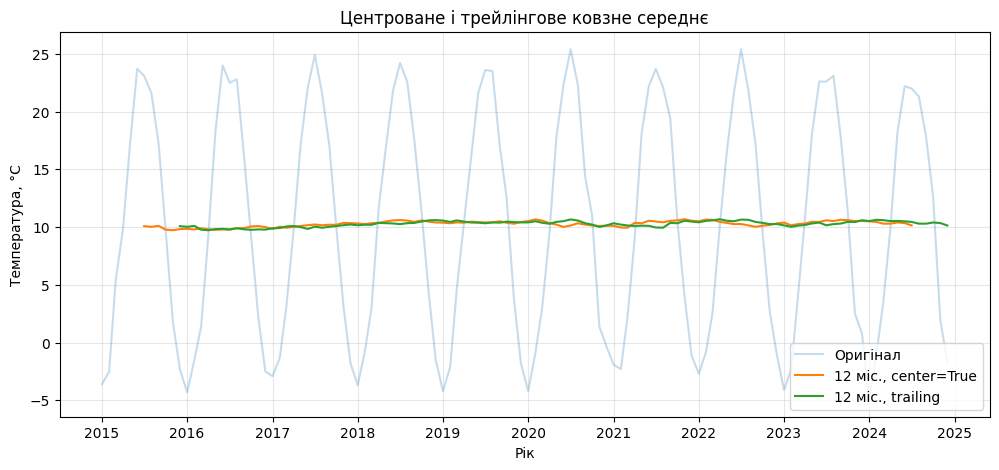

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    climate_ts.index,
    climate_ts.values,
    alpha=0.25,
    label="Оригінал"
)

ax.plot(
    ma12_center.index,
    ma12_center.values,
    label="12 міс., center=True"
)

ax.plot(
    ma12_trailing.index,
    ma12_trailing.values,
    label="12 міс., trailing"
)

ax.set_xlabel("Рік")
ax.set_ylabel("Температура, °C")
ax.set_title(
    "Центроване і трейлінгове ковзне середнє"
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

Ковзне середнє з вікном 3 місяці згладжує
випадкові короткочасні коливання, але річна
сезонна хвиля все ще добре помітна.

Вікно 12 місяців згладжує ряд значно сильніше
і майже прибирає річну сезонність.

Причина полягає в тому, що 12 місяців — це повний
період сезонного циклу. В одному вікні одночасно
враховуються зимові, весняні, літні та осінні
значення, тому сезонні відхилення значною мірою
компенсують одне одного.

У результаті 12-місячне середнє краще показує
повільний довгостроковий тренд.

Центроване ковзне середнє прив'язує результат
приблизно до середини вікна, тому краще показує,
де фактично знаходиться тренд.

Трейлінгове середнє використовує поточне та
попередні спостереження. Через це на графіку
воно систематично відстає від змін ряду —
виникає лаг.

Перевагою трейлінгового середнього є те, що його
можна обчислювати в реальному часі, не знаючи
майбутніх значень.

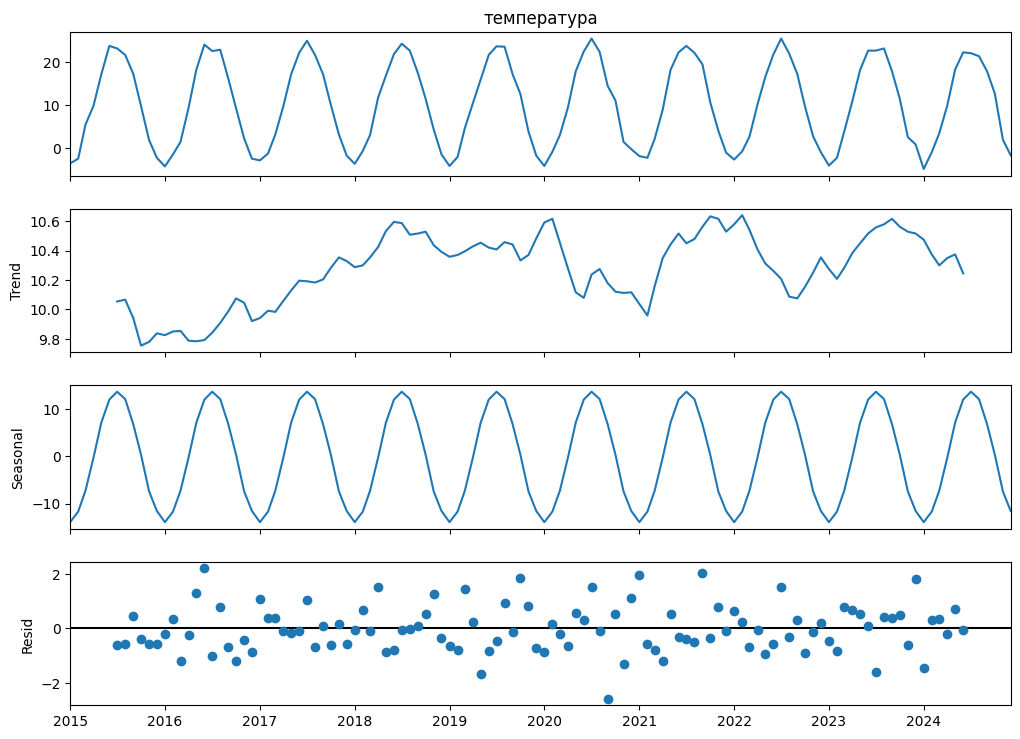

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    climate_ts,
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(11, 8)

plt.show()

In [8]:
seasonal_by_month = (
    decomposition.seasonal
    .groupby(decomposition.seasonal.index.month)
    .mean()
)

print(
    "Середня сезонна складова за місяцями:"
)

print(seasonal_by_month.round(2))

Середня сезонна складова за місяцями:
1    -13.91
2    -11.68
3     -7.25
4     -0.25
5      7.13
6     12.00
7     13.66
8     12.11
9      6.80
10     0.33
11    -7.40
12   -11.55
Name: seasonal, dtype: float64


In [9]:
warmest_month = seasonal_by_month.idxmax()
coldest_month = seasonal_by_month.idxmin()

print(
    "Найбільший сезонний ефект:",
    warmest_month
)

print(
    "Найменший сезонний ефект:",
    coldest_month
)

Найбільший сезонний ефект: 7
Найменший сезонний ефект: 1


In [10]:
resid_std = (
    decomposition.resid
    .dropna()
    .std()
)

print(
    "Стандартне відхилення залишків:",
    resid_std
)

Стандартне відхилення залишків: 0.8663285104262615


Декомпозиція розділила часовий ряд на три основні
компоненти: тренд, сезонність і залишок.

1. Тренд

Оцінений тренд має загалом повільно зростаючий
характер.

Це узгоджується з генерацією даних, де було
закладено потепління 0.04 °C на рік.

Зростання невелике порівняно із сезонними
коливаннями, тому на початковому графіку воно
було значно менш помітним.

2. Сезонність

Найбільший сезонний ефект отримано для 7-го місяця,
тобто липня:

приблизно +13.66 °C.

Найменший сезонний ефект — для січня:

приблизно -13.91 °C.

Це добре узгоджується із заданою амплітудою 14 °C
та формулою генерації, за якою температурний максимум
розташований приблизно в липні.

3. Залишки

Стандартне відхилення залишків становить приблизно:

0.87 °C.

При генерації даних було задано:

noise_scale = 1.0 °C.

Отриманий результат є близьким до закладеного рівня
випадкового шуму.

Отже, декомпозиція достатньо добре відновила
основні компоненти синтетичного часового ряду.

In [11]:
from scipy.stats import linregress

trend_clean = (
    decomposition.trend
    .dropna()
)

x = np.arange(
    len(trend_clean)
)

fit = linregress(
    x,
    trend_clean.values
)

print(
    "Нахил, °C/місяць:",
    fit.slope
)

print(
    "Нахил, °C/рік:",
    fit.slope * 12
)

print(
    "p-value:",
    fit.pvalue
)

print(
    "stderr:",
    fit.stderr
)

Нахил, °C/місяць: 0.004478887809184465
Нахил, °C/рік: 0.05374665371021358
p-value: 3.019748866781855e-11
stderr: 0.0006034230000743554


In [12]:
n_ahead = 12

x_future = np.arange(
    len(trend_clean),
    len(trend_clean) + n_ahead
)

trend_forecast = (
    fit.intercept
    + fit.slope * x_future
)

future_dates = pd.date_range(
    climate_ts.index[-1]
    + pd.offsets.MonthBegin(1),
    periods=n_ahead,
    freq="MS"
)

seasonal_forecast = (
    seasonal_by_month
    .reindex(future_dates.month)
    .values
)

forecast = pd.Series(
    trend_forecast + seasonal_forecast,
    index=future_dates,
    name="прогноз"
)

print(forecast.round(1))

2025-01-01    -3.4
2025-02-01    -1.2
2025-03-01     3.3
2025-04-01    10.3
2025-05-01    17.7
2025-06-01    22.5
2025-07-01    24.2
2025-08-01    22.7
2025-09-01    17.4
2025-10-01    10.9
2025-11-01     3.2
2025-12-01    -1.0
Freq: MS, Name: прогноз, dtype: float64


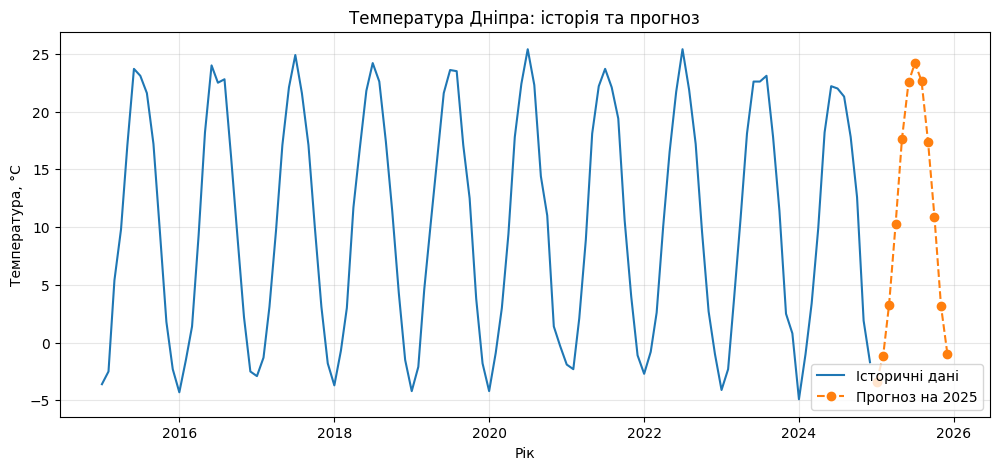

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    climate_ts.index,
    climate_ts.values,
    label="Історичні дані"
)

ax.plot(
    forecast.index,
    forecast.values,
    marker="o",
    linestyle="--",
    label="Прогноз на 2025"
)

ax.set_xlabel("Рік")
ax.set_ylabel("Температура, °C")

ax.set_title(
    "Температура Дніпра: історія та прогноз"
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

За оціненим трендом температура збільшується
приблизно на 0.00448 °C за місяць, або приблизно
на 0.054 °C за рік.

Для прогнозу на 2025 рік до продовженого тренду
було додано типовий сезонний ефект кожного
календарного місяця.

У результаті прогноз зберігає характерний річний
цикл: найнижчі температури прогнозуються взимку,
а максимальні — в липні.

Наприклад, прогноз для січня 2025 року становить
приблизно -3.4 °C, а для липня — приблизно 24.2 °C.

Однак ці значення не потрібно сприймати як точний
прогноз реальної погоди.

Модель механічно припускає, що оцінений за
2015–2024 роки лінійний тренд і типова сезонність
продовжаться в майбутньому без змін.

У реальному світі температура окремих місяців
залежить від великої кількості атмосферних і
кліматичних факторів, яких у цій простій моделі немає.

Також сам довгостроковий темп зміни клімату
не зобов'язаний залишатися абсолютно постійним.

Тому зі збільшенням горизонту прогнозу невизначеність
зростає, а механічна екстраполяція лінійного тренду
стає менш надійною.

slope ≈ 0.004479 °C/місяць
p-value ≈ 3.02 × 10⁻¹¹

Перевіримо гіпотези:

H0: істинний нахил тренду дорівнює нулю,
тобто реального довгострокового потепління немає,
а видимі зміни пояснюються випадковим шумом.

H1: істинний нахил тренду не дорівнює нулю.

Для тренду отримано:

slope ≈ 0.00448 °C/місяць;

p-value ≈ 3.02 × 10⁻¹¹.

При рівні значущості α = 0.05:

p-value < 0.05.

Тому нульову гіпотезу H0 відхиляємо.

Для цього синтетичного 10-річного набору є
статистично значущі свідчення ненульового
лінійного тренду.

Оскільки оцінений нахил додатний, напрямок
виявленого тренду відповідає потеплінню.

In [14]:
lower = (
    fit.slope
    - 1.96 * fit.stderr
)

upper = (
    fit.slope
    + 1.96 * fit.stderr
)

print(
    "95% ДІ для нахилу, °C/місяць:"
)

print(lower, upper)

print(
    "\n95% ДІ, °C/рік:"
)

print(
    lower * 12,
    upper * 12
)

95% ДІ для нахилу, °C/місяць:
0.0032961787290387286 0.005661596889330201

95% ДІ, °C/рік:
0.03955414474846474 0.06793916267196241


Приблизний 95% довірчий інтервал для істинного
нахилу становить:

[0.00330; 0.00566] °C/місяць.

У перерахунку на рік:

[0.0396; 0.0679] °C/рік.

Нуль не входить до цього довірчого інтервалу.

Це узгоджується з результатом перевірки гіпотези:
p-value значно менше 0.05.

Закладений при генерації тренд становив
0.04 °C/рік і знаходиться всередині отриманого
довірчого інтервалу.

In [15]:
# Останні 2 роки очищеного тренду
trend_2y = trend_clean.iloc[-24:]

fit_2y = linregress(
    np.arange(len(trend_2y)),
    trend_2y.values
)

# Останні 3 роки
trend_3y = trend_clean.iloc[-36:]

fit_3y = linregress(
    np.arange(len(trend_3y)),
    trend_3y.values
)

print("ВСІ 10 РОКІВ")
print(
    "slope за рік:",
    fit.slope * 12
)
print(
    "p-value:",
    fit.pvalue
)

print("\nОСТАННІ 2 РОКИ")
print(
    "slope за рік:",
    fit_2y.slope * 12
)
print(
    "p-value:",
    fit_2y.pvalue
)

print("\nОСТАННІ 3 РОКИ")
print(
    "slope за рік:",
    fit_3y.slope * 12
)
print(
    "p-value:",
    fit_3y.pvalue
)

ВСІ 10 РОКІВ
slope за рік: 0.05374665371021358
p-value: 3.019748866781855e-11

ОСТАННІ 2 РОКИ
slope за рік: 0.1416304347826093
p-value: 0.008339713523762147

ОСТАННІ 3 РОКИ
slope за рік: -0.026994851994851875
p-value: 0.389256513258011


При використанні всього 10-річного ряду оцінений
нахил становить приблизно +0.054 °C/рік і є
статистично значущим.

Якщо взяти лише останні 2 роки, оцінка стає
значно більшою:

приблизно +0.142 °C/рік.

Якщо ж взяти останні 3 роки, оцінений нахил
навіть змінює знак:

приблизно -0.027 °C/рік,

а p-value ≈ 0.389 > 0.05.

Отже, оцінка тренду на короткому часовому вікні
є значно нестабільнішою.

Причина полягає в тому, що на короткому проміжку
випадкові коливання сильніше впливають на нахил
регресійної прямої.

На довшому 10-річному ряді випадковий шум частково
усереднюється, тому повільний систематичний тренд
можна оцінити надійніше.

Цей результат показує, чому не можна робити висновок
про довгострокове потепління лише за коротким
відрізком часового ряду.

Для всього 10-річного ряду Дніпра отримано
статистично підтверджений додатний тренд.

Цей висновок ґрунтується не лише на тому,
що slope > 0.

Основні аргументи:

1. Оцінений нахил ≈ +0.0537 °C/рік.

2. p-value ≈ 3.02 × 10⁻¹¹, що значно менше 0.05.

3. 95% довірчий інтервал для нахилу становить
приблизно [0.0396; 0.0679] °C/рік і не містить 0.

Отже, для цього синтетичного набору є статистичні
підстави говорити про додатний довгостроковий тренд,
а не лише про випадкову лінію, яка візуально
спрямована вгору.

Порівняння з останніми 2–3 роками також показало,
що короткі часові вікна дають значно нестабільніші
оцінки через сильніший вплив випадкового шуму.

1. Чому часовий ряд не можна аналізувати так само,
як звичайну незалежну вибірку?

У звичайній незалежній вибірці припускається,
що спостереження не залежать одне від одного.

У часовому ряді порядок спостережень має значення.

Наприклад, температури мають сезонність:
значення в січні систематично відрізняються
від значень у липні.

Також у нашому ряді присутній довгостроковий тренд.

Отже, розподіл температури змінюється залежно
від моменту часу, а сусідні та сезонно відповідні
спостереження мають часову структуру.

Якщо ігнорувати цю структуру й аналізувати ряд
як звичайну незалежну вибірку, можна втратити
інформацію про тренд і сезонність та отримати
некоректні статистичні висновки.


2. Чому надто мале і надто велике вікно ковзного
середнього є проблемою?

Надто мале вікно згладжує ряд недостатньо.

Наприклад, вікно 3 місяці прибирає частину
короткочасного шуму, але в ньому все ще добре
видно річну сезонність.

Надто велике вікно, навпаки, може надмірно
згладити ряд і приховати важливі зміни тренду.

Воно також призводить до втрати більшої кількості
значень на краях при центрованому згладжуванні.

Розмір вікна доцільно узгоджувати з періодом
сезонності.

Для нашого щомісячного ряду сезонний період
дорівнює 12 місяцям, тому вікно 12 добре
прибирає річну сезонну хвилю та залишає
переважно довгостроковий тренд.


3. У чому різниця між трейлінговим і центрованим
ковзним середнім?

Трейлінгове ковзне середнє використовує поточне
та попередні значення.

Тому воно доступне в реальному часі, але реагує
на зміни із запізненням — на графіку виникає лаг.

Центроване середнє розташовує вікно навколо
поточного моменту часу.

Через це оцінка краще прив'язана до фактичного
положення тренду і має менший систематичний лаг.

Проте для її обчислення потрібні також майбутні
значення.

Наприклад, щоб знайти центроване середнє для
певного місяця, потрібно знати частину температур
після цього місяця.

Тому center=True зручно використовувати для
аналізу історичних даних, але його неможливо
повністю обчислити в реальному часі.


4. Чому саме p-value нахилу, а не тільки знак slope,
визначає статистичне підтвердження тренду?

Додатне значення slope саме по собі означає лише,
що регресійна пряма в конкретній вибірці спрямована
вгору.

Навіть якщо справжнього тренду немає, випадковий
шум може випадково створити додатний або від'ємний
нахил.

Тому потрібно перевірити:

H0: істинний нахил = 0.

p-value показує, наскільки отриманий нахил
сумісний із цією нульовою гіпотезою.

Для нашого 10-річного ряду:

slope ≈ +0.0537 °C/рік;

p-value ≈ 3.02 × 10⁻¹¹.

Оскільки p-value < 0.05, H0 відхиляємо.

Крім того, 95% довірчий інтервал:

[0.0396; 0.0679] °C/рік

не містить нуля.

Тому в цьому синтетичному наборі є статистичні
підстави говорити про додатний тренд.

Саме знак slope визначає напрямок тренду,
а p-value та довірчий інтервал допомагають
оцінити, чи цей тренд статистично відрізняється
від нульового.